# Fase 0 - Exploración del Dataset IroSvA
Análisis estadístico descriptivo de las tres variantes dialectales del corpus IroSvA
(Ortega-Bueno et al., 2019): distribución de clases, presencia de variables lingüísticas
relevantes para detección de ironía y análisis del vocabulario.
Los resultados se presentan por variante dialectal y para el corpus completo.

## 1. Importación de librerías

In [1]:
import pandas as pd
import re
import emoji
import unicodedata
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 2. Carga de las tres variantes dialectales

In [2]:
df_mx = pd.read_csv('../data/irosva.mx.training.csv')
df_es = pd.read_csv('../data/irosva.es.training.csv')
df_cu = pd.read_csv('../data/irosva.cu.training.csv')

# Dataset combinado
df_all = pd.concat([df_mx, df_es, df_cu], ignore_index=True)

# Estructura unificada para iterar sobre variantes + total
DATASETS = [
    ('México',              df_mx),
    ('España',              df_es),
    ('Cuba',                df_cu),
    ('TOTAL (3 variantes)', df_all)
]

print(f'Columnas: {df_mx.columns.tolist()}')
print(f'Tipos:    {df_mx.dtypes.to_dict()}')
print(df_mx.head(3))

Columnas: ['ID', 'TOPIC', 'IS_IRONIC', 'MESSAGE']
Tipos:    {'ID': <StringDtype(storage='python', na_value=nan)>, 'TOPIC': <StringDtype(storage='python', na_value=nan)>, 'IS_IRONIC': dtype('int64'), 'MESSAGE': <StringDtype(storage='python', na_value=nan)>}
                                 ID           TOPIC  IS_IRONIC  \
0  6424ee0864a0af40660686e135f5652b  asuntosConacyt          1   
1  f59978451dd7fb228830fed2ae00c3ef  asuntosConacyt          1   
2  280963c5eb0d162858caf3480a7ea08c  asuntosConacyt          1   

                                             MESSAGE  
0  Rica económicamente, pero muy pobre en objetiv...  
1  En algo tiene razón, mafias hay en todo, hasta...  
2  ¿De cuándo acá tan preocupados por la ciencia ...  


## 3. Validación de calidad: nulos y duplicados

In [3]:
for nombre, df in DATASETS:
    nulos = df.isnull().sum().sum()
    dups  = df.duplicated(subset='MESSAGE').sum()
    print(f'{nombre:25} {nulos} nulos | {dups} duplicados en MESSAGE')

México                    0 nulos | 1 duplicados en MESSAGE
España                    0 nulos | 2 duplicados en MESSAGE
Cuba                      0 nulos | 0 duplicados en MESSAGE
TOTAL (3 variantes)       0 nulos | 3 duplicados en MESSAGE


## 4. Distribución de clases
El dataset presenta un desbalance 2:1 (no irónico:irónico) consistente
en las tres variantes (Ortega-Bueno et al., 2019).

In [4]:
print(f'{"Variante":25} {"Total":>7} {"Irónico":>10} {"No irónico":>12}')
print('-' * 58)
for nombre, df in DATASETS:
    total      = len(df)
    ironico    = df['IS_IRONIC'].sum()
    no_ironico = total - ironico
    print(f'{nombre:25} {total:>7,} '
          f'{ironico:>5} ({ironico/total*100:.1f}%) '
          f'{no_ironico:>5} ({no_ironico/total*100:.1f}%)')

Variante                    Total    Irónico   No irónico
----------------------------------------------------------
México                      2,400   800 (33.3%)  1600 (66.7%)
España                      2,400   800 (33.3%)  1600 (66.7%)
Cuba                        2,400   800 (33.3%)  1600 (66.7%)
TOTAL (3 variantes)         7,200  2400 (33.3%)  4800 (66.7%)


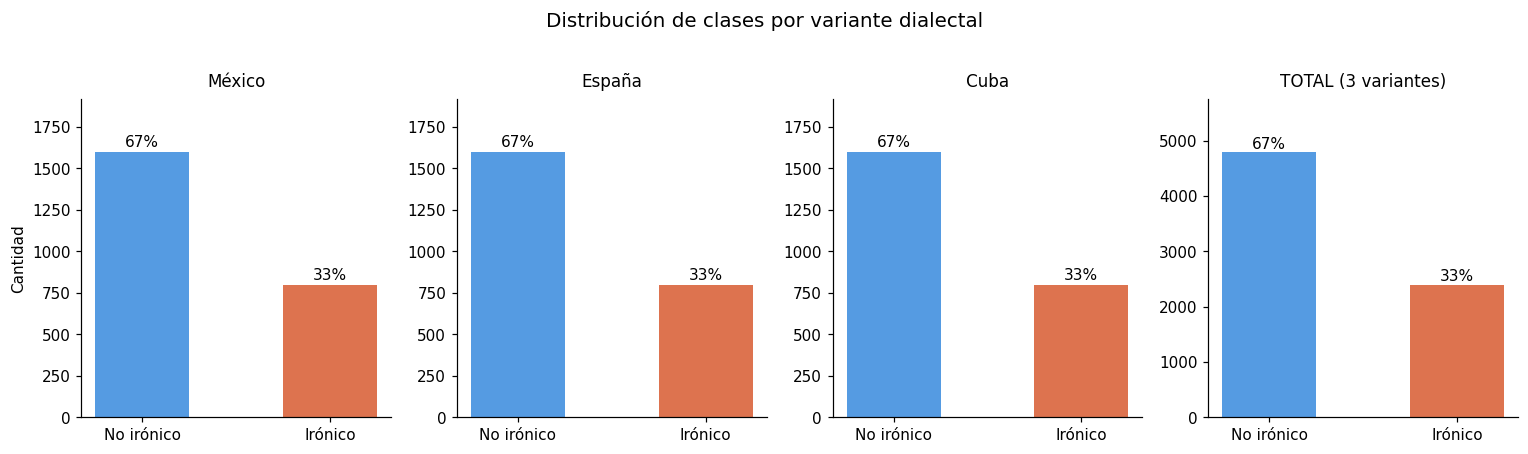

In [5]:
# Visualización del balance de clases por variante
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
colores = ['#378ADD', '#D85A30']
etiquetas = ['No irónico', 'Irónico']

for ax, (nombre, df) in zip(axes, DATASETS):
    conteos = df['IS_IRONIC'].value_counts().sort_index()
    bars = ax.bar(etiquetas, conteos.values, color=colores, width=0.5, alpha=0.85)
    ax.set_title(nombre, fontsize=11, pad=8)
    ax.set_ylabel('Cantidad' if ax == axes[0] else '')
    for bar, v in zip(bars, conteos.values):
        pct = v / len(df) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{pct:.0f}%', ha='center', va='bottom', fontsize=10)
    ax.set_ylim(0, conteos.max() * 1.2)

fig.suptitle('Distribución de clases por variante dialectal', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Ejemplos de tweets irónicos y no irónicos

In [6]:
for nombre, df in DATASETS[:-1]:  # solo las 3 variantes, no el total
    print(f'\n=== {nombre.upper()} — TWEETS IRÓNICOS ===')
    for tweet in df[df['IS_IRONIC']==1]['MESSAGE'].head(3).values:
        print(' -', tweet)
    print(f'\n=== {nombre.upper()} — TWEETS NO IRÓNICOS ===')
    for tweet in df[df['IS_IRONIC']==0]['MESSAGE'].head(3).values:
        print(' -', tweet)


=== MÉXICO — TWEETS IRÓNICOS ===
 - Rica económicamente, pero muy pobre en objetividad.
 - En algo tiene razón, mafias hay en todo, hasta en su 4t.
 - ¿De cuándo acá tan preocupados por la ciencia y la investigación?

=== MÉXICO — TWEETS NO IRÓNICOS ===
 - Lo más grave es que en la entrevista menciona que, el modelo científico que debemos seguir es el de Cuba. ¿De dónde salió ésta gente? Su visión del mundo es completamente anacrónica y desinformada.
 - Y tanta gente capacitada que se fue a  la banca por causa de estos ineptos
 - De nada; si se van a gastar mis impuestos que mejor que sea en algo que nos mejore como país.

=== ESPAÑA — TWEETS IRÓNICOS ===
 - @ArmandoRuido007 @ANTI_MERMA50 @JoanTarda En vez de Joan Tarda van a llamarle “No han tarda” en callarle la boca 🤣🤣
 - @El_Plural Joan Tardà responderá a Vox en catalán....si, si, https://t.co/EpShFy8OfV
 - @orioldebalanzo Que hayan dejado marcharse libre a Joan Tardà eleva la media de la Justicia española. Ya casi somos Turquía.


## 6. Extracción y análisis de variables lingüísticas por clase

Se analizan 9 variables lingüísticas asociadas a la detección de sarcasmo:
exclamaciones, interrogaciones, mayúsculas enfáticas, emojis, risas, negaciones,
elongación de caracteres, comillas y puntos suspensivos
(González-Ibáñez et al., 2011; Joshi et al., 2015, 2017; Šandor & Bagić Babac, 2023).

Todas se extraen del texto original **antes del preprocesamiento** para capturar
emojis, elongación y signos de puntuación en su forma natural.

In [7]:
# ── UTILIDAD: normalización de tildes ────────────────────────────────────────
def quitar_tildes(texto):
    return ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

# ── LISTA DE NEGACIONES EN ESPAÑOL ───────────────────────────────────────────
NEGACIONES = {
    'no', 'nunca', 'jamas', 'tampoco',
    'nada', 'nadie',
    'ningun', 'ninguno', 'ninguna', 'ningunos', 'ningunas',
    'ni', 'sino',
    'sin'
}

# ── NOMBRES DE FEATURES ──────────────────────────────────────────────────────
FEATURES = ['n_exc','n_int','n_may','n_emo','n_ris','n_neg','n_elo','n_com','n_pun']
NOMBRES  = [
    'Exclamaciones', 'Interrogaciones', 'Mayúsculas enfáticas',
    'Emojis', 'Risas', 'Negaciones',
    'Elongación', 'Comillas', 'Puntos suspensivos'
]

In [8]:
def extraer_features(texto):
    texto_str  = str(texto)
    texto_norm = quitar_tildes(texto_str.lower())
    palabras   = re.findall(r'\b\w+\b', texto_norm)

    n_exc = texto_str.count('!') + texto_str.count('¡')
    n_int = texto_str.count('?') + texto_str.count('¿')
    n_may = len(re.findall(r'\b[A-ZÁÉÍÓÚÜÑ]{3,}\b', texto_str))
    n_emo = sum(1 for c in texto_str if c in emoji.EMOJI_DATA)
    n_ris = len(re.findall(
        r'\b(ja+ja+|je+je+|ji+ji+|ha+ha+|xs+|xd+|lol+|jsjs)\b',
        texto_norm
    ))
    n_neg = sum(1 for p in palabras if p in NEGACIONES)
    n_elo = len(re.findall(r'(.)\1{2,}', texto_norm))
    n_com = len(re.findall(r'["\'‘’“”«»]', texto_str))
    n_pun = texto_str.count('...') + texto_str.count('…')

    return {
        'n_exc': n_exc, 'n_int': n_int, 'n_may': n_may,
        'n_emo': n_emo, 'n_ris': n_ris, 'n_neg': n_neg,
        'n_elo': n_elo, 'n_com': n_com, 'n_pun': n_pun
    }

In [9]:
def analizar_features(nombre, df):
    feats = df['MESSAGE'].apply(extraer_features).apply(pd.Series)
    df_f  = pd.concat([df[['IS_IRONIC']], feats], axis=1)

    print(f'\n{"="*58}')
    print(f'  {nombre}')
    print(f'{"="*58}')

    print(f'\n  Presencia (% de textos con al menos 1 ocurrencia):')
    print(f'  {"Variable":23} {"No irónico":>12} {"Irónico":>10}')
    print(f'  {"-"*48}')
    for feat, nom in zip(FEATURES, NOMBRES):
        p = df_f.groupby('IS_IRONIC')[feat].apply(lambda x: (x>0).mean()*100)
        print(f'  {nom:23} {p[0]:>11.1f}% {p[1]:>9.1f}%')

    print(f'\n  Media de ocurrencias por texto:')
    print(f'  {"Variable":23} {"No irónico":>12} {"Irónico":>10}')
    print(f'  {"-"*48}')
    for feat, nom in zip(FEATURES, NOMBRES):
        m = df_f.groupby('IS_IRONIC')[feat].mean()
        print(f'  {nom:23} {m[0]:>12.3f} {m[1]:>10.3f}')

    return df_f

# Ejecutar para cada variante y el total
resultados = {}
for nombre, df in DATASETS:
    resultados[nombre] = analizar_features(nombre, df)


  México

  Presencia (% de textos con al menos 1 ocurrencia):
  Variable                  No irónico    Irónico
  ------------------------------------------------
  Exclamaciones                  14.4%      20.6%
  Interrogaciones                18.3%      20.6%
  Mayúsculas enfáticas           14.4%      13.0%
  Emojis                          7.9%      16.6%
  Risas                           0.4%       0.9%
  Negaciones                     43.9%      37.1%
  Elongación                     18.4%      32.2%
  Comillas                        5.9%       9.5%
  Puntos suspensivos             12.1%      18.5%

  Media de ocurrencias por texto:
  Variable                  No irónico    Irónico
  ------------------------------------------------
  Exclamaciones                  0.374      0.585
  Interrogaciones                0.371      0.412
  Mayúsculas enfáticas           0.566      0.359
  Emojis                         0.207      0.534
  Risas                          0.005      0.009

### 6.1 Distribución de cada feature numérica
Histogramas de las 9 features para el corpus completo.
Permite identificar el grado de sesgo, presencia de outliers y features casi siempre en cero,
lo que determina la elección del escalador (RobustScaler vs StandardScaler) y si aplicar log1p.

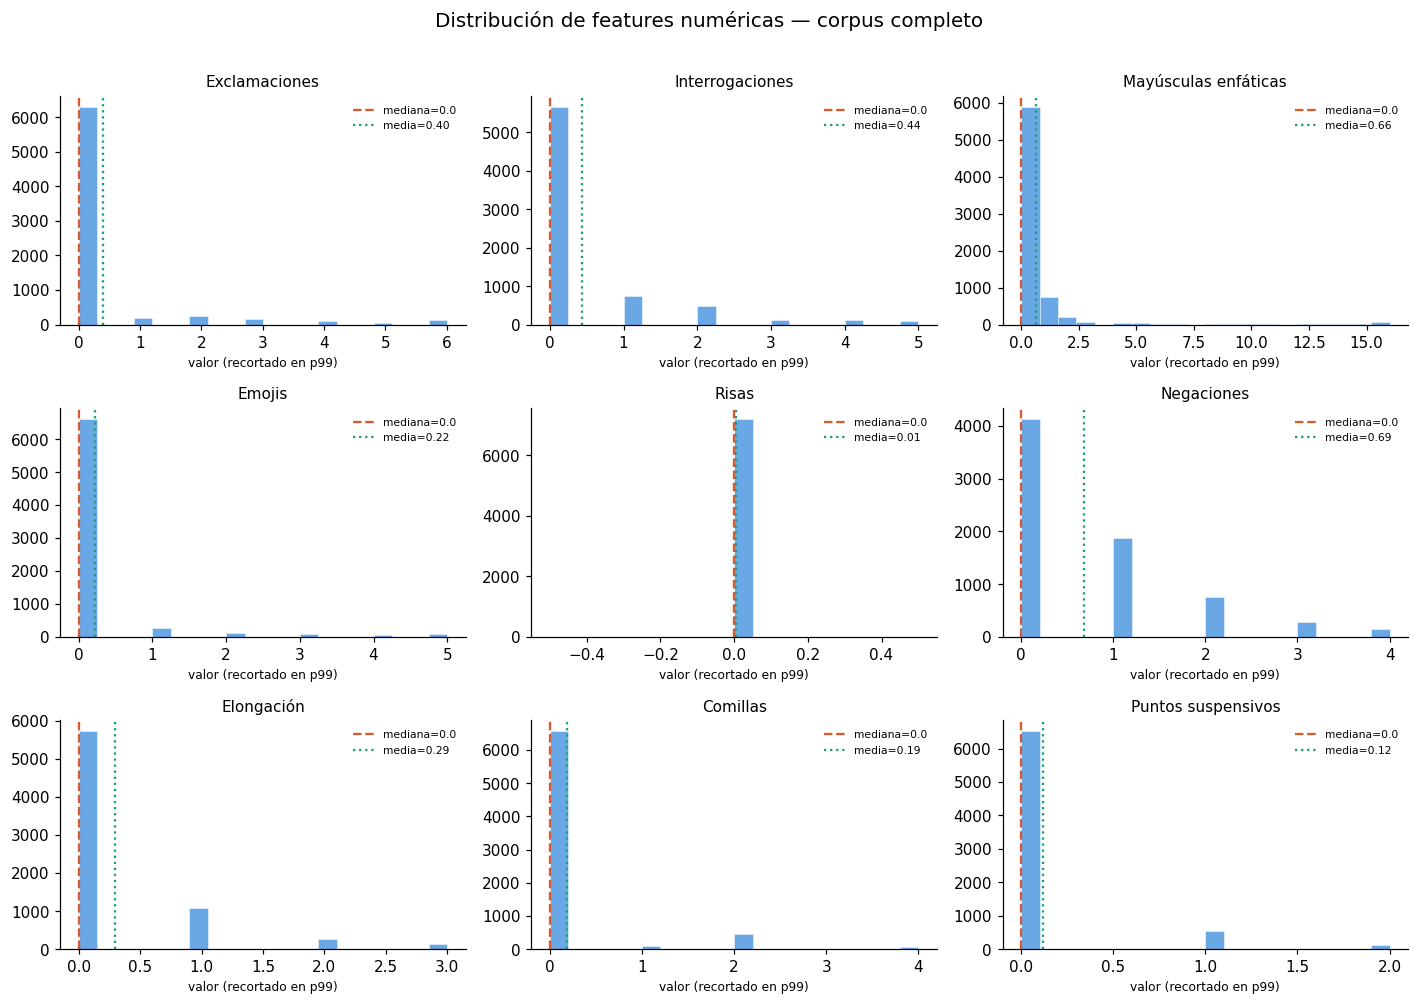


Estadísticos descriptivos (corpus completo):
          n_exc     n_int     n_may     n_emo     n_ris     n_neg     n_elo     n_com     n_pun
                                                                                               
count  7200.000  7200.000  7200.000  7200.000  7200.000  7200.000  7200.000  7200.000  7200.000
mean      0.401     0.436     0.657     0.223     0.006     0.686     0.292     0.190     0.121
std       1.460     1.160     2.878     1.096     0.077     1.009     0.711     0.676     0.435
min       0.000     0.000     0.000     0.000     0.000     0.000     0.000     0.000     0.000
25%       0.000     0.000     0.000     0.000     0.000     0.000     0.000     0.000     0.000
50%       0.000     0.000     0.000     0.000     0.000     0.000     0.000     0.000     0.000
75%       0.000     0.000     0.000     0.000     0.000     1.000     0.000     0.000     0.000
90%       1.000     2.000     1.000     0.000     0.000     2.000     1.000     0.000     

In [10]:
df_feats_all = resultados['TOTAL (3 variantes)']

fig, axes = plt.subplots(3, 3, figsize=(13, 9))
axes = axes.flatten()

for i, (feat, nom) in enumerate(zip(FEATURES, NOMBRES)):
    ax = axes[i]
    vals = df_feats_all[feat]
    p95  = vals.quantile(0.95)
    # recortar en p99 para no colapsar el eje por outliers extremos
    ax.hist(vals.clip(upper=vals.quantile(0.99)),
            bins=20, color='#378ADD', alpha=0.75, edgecolor='white', linewidth=0.4)
    ax.axvline(vals.median(), color='#D85A30', linewidth=1.5,
               linestyle='--', label=f'mediana={vals.median():.1f}')
    ax.axvline(vals.mean(),   color='#1D9E75', linewidth=1.5,
               linestyle=':',  label=f'media={vals.mean():.2f}')
    ax.set_title(nom, fontsize=10)
    ax.set_xlabel('valor (recortado en p99)', fontsize=8)
    ax.legend(fontsize=7, frameon=False)

fig.suptitle('Distribución de features numéricas — corpus completo', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Tabla de estadísticos descriptivos
print('\nEstadísticos descriptivos (corpus completo):')
desc = df_feats_all[FEATURES].describe(percentiles=[.25, .5, .75, .90, .95, .99])
desc.index.name = ''
print(desc.round(3).to_string())

### 6.2 Distribución por clase (irónico vs. no irónico)
Boxplots comparativos por clase para cada feature.
Las features con distribuciones claramente distintas entre clases son las más discriminativas para el modelo.
Las que solapan completamente aportan poco y podrían descartarse.

/var/folders/5h/kdhzvpmx2x5977dp_tv71f6m0000gn/T/ipykernel_41325/2396188015.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/5h/kdhzvpmx2x5977dp_tv71f6m0000gn/T/ipykernel_41325/2396188015.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/5h/kdhzvpmx2x5977dp_tv71f6m0000gn/T/ipykernel_41325/2396188015.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/5h/kdhzvpmx2x5977dp_tv71f6m0000gn/T/ipykernel_41325/2396188015.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

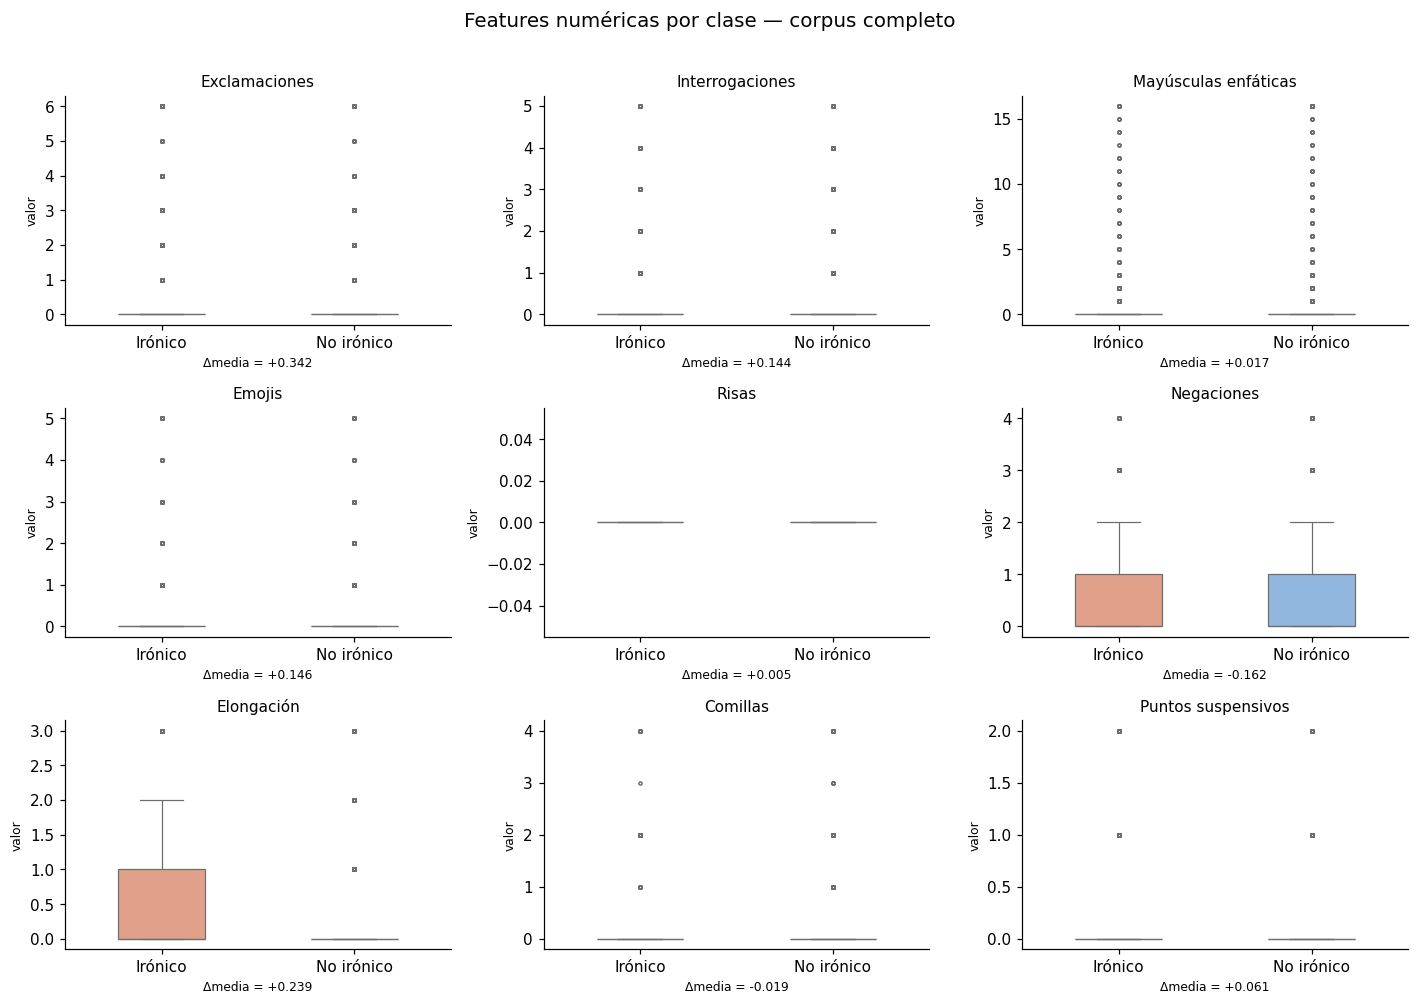


Media por clase (corpus completo):
            n_exc  n_int  n_may  n_emo  n_ris  n_neg  n_elo  n_com  n_pun
IS_IRONIC                                                                
No irónico  0.287  0.388  0.651  0.174  0.004  0.740  0.213  0.196  0.101
Irónico     0.629  0.532  0.668  0.320  0.009  0.578  0.452  0.178  0.162


In [11]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
axes = axes.flatten()

for i, (feat, nom) in enumerate(zip(FEATURES, NOMBRES)):
    ax = axes[i]
    data_plot = df_feats_all[[feat, 'IS_IRONIC']].copy()
    data_plot['Clase'] = data_plot['IS_IRONIC'].map({0: 'No irónico', 1: 'Irónico'})
    # recortar outliers extremos para legibilidad
    p99 = data_plot[feat].quantile(0.99)
    data_plot[feat] = data_plot[feat].clip(upper=p99)

    sns.boxplot(
        data=data_plot, x='Clase', y=feat,
        palette={'No irónico': '#85B7EB', 'Irónico': '#F0997B'},
        width=0.45, linewidth=0.8, fliersize=2, ax=ax
    )
    ax.set_title(nom, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('valor', fontsize=8)

    # Diferencia de medias como anotación
    m0 = df_feats_all.loc[df_feats_all['IS_IRONIC']==0, feat].mean()
    m1 = df_feats_all.loc[df_feats_all['IS_IRONIC']==1, feat].mean()
    ax.set_xlabel(f'Δmedia = {m1-m0:+.3f}', fontsize=8)

fig.suptitle('Features numéricas por clase — corpus completo', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Tabla de medias por clase
print('\nMedia por clase (corpus completo):')
print(df_feats_all.groupby('IS_IRONIC')[FEATURES]
      .mean().rename(index={0:'No irónico', 1:'Irónico'}).round(3).to_string())

### 6.3 Correlación entre features numéricas
Features muy correlacionadas (|r| > 0.85) son redundantes: aportan la misma información
al modelo. SVM no falla por esto, pero reducir redundancia disminuye ruido.

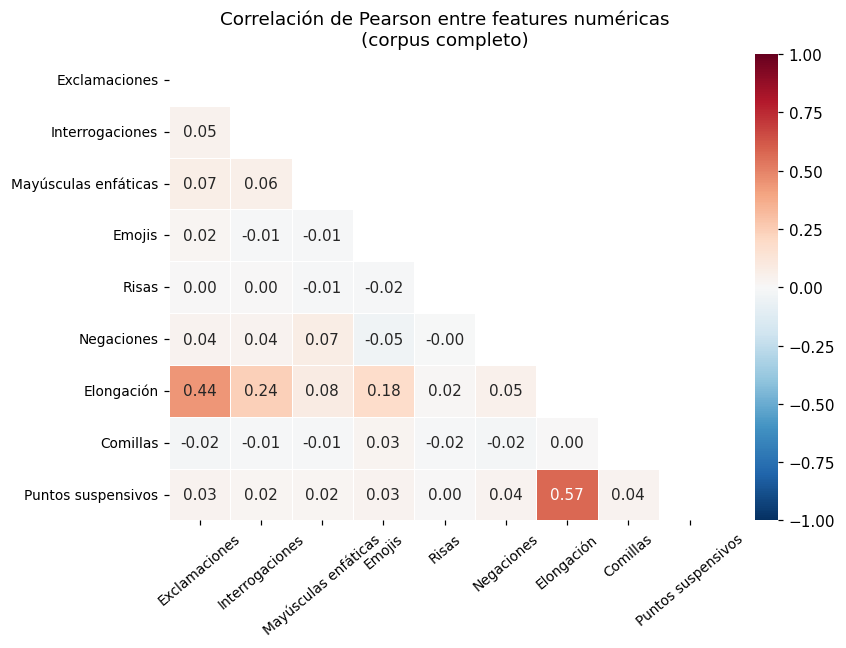


Pares con |r| > 0.5:
  Elongación                — Puntos suspensivos         r = 0.571


In [12]:
corr = df_feats_all[FEATURES].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))  # ocultar triángulo superior
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, linecolor='white',
    xticklabels=NOMBRES, yticklabels=NOMBRES,
    ax=ax
)
ax.set_title('Correlación de Pearson entre features numéricas\n(corpus completo)', fontsize=12)
ax.tick_params(axis='x', rotation=40, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.show()

# Pares con correlación alta
umbral = 0.5
pares_altos = [
    (NOMBRES[i], NOMBRES[j], corr.iloc[i, j])
    for i in range(len(FEATURES))
    for j in range(i+1, len(FEATURES))
    if abs(corr.iloc[i, j]) > umbral
]
if pares_altos:
    print(f'\nPares con |r| > {umbral}:')
    for a, b, r in sorted(pares_altos, key=lambda x: -abs(x[2])):
        print(f'  {a:25} — {b:25}  r = {r:.3f}')
else:
    print(f'No hay pares con |r| > {umbral}')

### 6.4 Distribución de valores y decisión de escalador
Comparación visual del efecto de StandardScaler vs RobustScaler sobre las features,
considerando la presencia de outliers.

/var/folders/5h/kdhzvpmx2x5977dp_tv71f6m0000gn/T/ipykernel_41325/1435549467.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/5h/kdhzvpmx2x5977dp_tv71f6m0000gn/T/ipykernel_41325/1435549467.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/5h/kdhzvpmx2x5977dp_tv71f6m0000gn/T/ipykernel_41325/1435549467.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


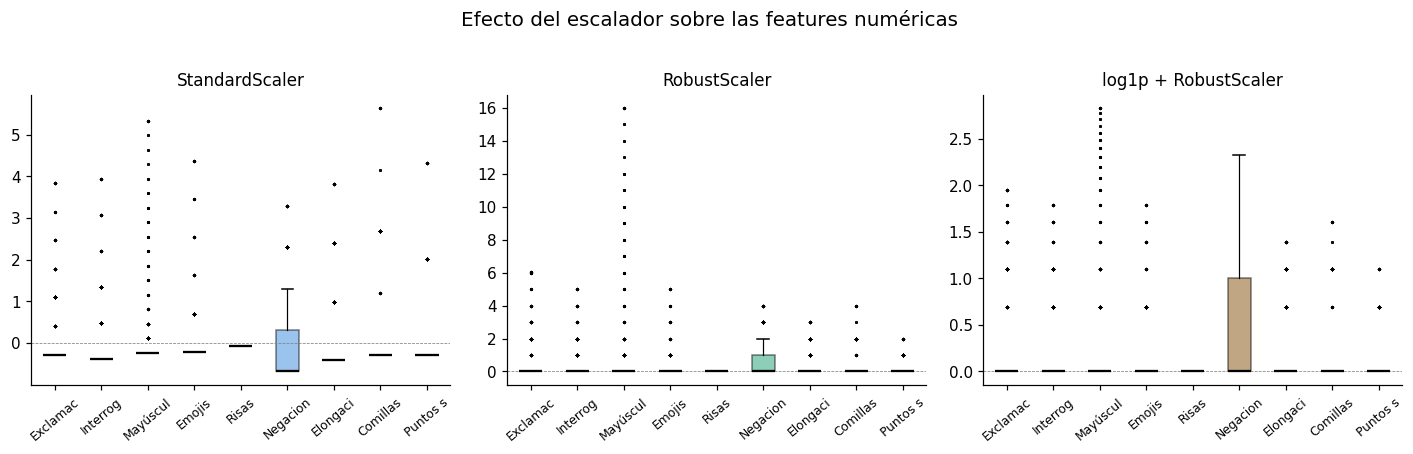

In [13]:
from sklearn.preprocessing import StandardScaler, RobustScaler

X_num = df_feats_all[FEATURES].values.astype(float)
X_std = StandardScaler().fit_transform(X_num)
X_rob = RobustScaler().fit_transform(X_num)
X_log_rob = RobustScaler().fit_transform(np.log1p(X_num))

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
configs = [
    (X_std,     'StandardScaler',       '#378ADD'),
    (X_rob,     'RobustScaler',         '#1D9E75'),
    (X_log_rob, 'log1p + RobustScaler', '#854F0B'),
]

for ax, (X_t, titulo, color) in zip(axes, configs):
    # rango intercuartílico promedio de todas las features escaladas
    df_t = pd.DataFrame(X_t, columns=FEATURES)
    ax.boxplot(
        [df_t[f].clip(*df_t[f].quantile([0.01, 0.99]).values) for f in FEATURES],
        labels=[n[:8] for n in NOMBRES],
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.5),
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(linewidth=0.8),
        flierprops=dict(marker='.', markersize=2, alpha=0.4)
    )
    ax.set_title(titulo, fontsize=11)
    ax.tick_params(axis='x', rotation=40, labelsize=8)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

fig.suptitle('Efecto del escalador sobre las features numéricas', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Análisis de vocabulario
Se analiza el tamaño del vocabulario por variante dialectal y en el corpus completo
para justificar el límite de 10 000 términos en la vectorización TF-IDF
(Pandey & Singh, 2023; Šandor & Bagić Babac, 2023).

In [14]:
def tokenizar_simple(texto):
    return re.findall(r'\b\w+\b', str(texto).lower())

print('Tamaño del vocabulario por variante (texto crudo, sin preprocesamiento):\n')
print(f'{"Variante":25} {"Tokens totales":>16} {"Vocabulario único":>18}')
print('-' * 62)

vocab_total = set()
for nombre, df in DATASETS[:-1]:
    tokens = [t for msg in df['MESSAGE'] for t in tokenizar_simple(msg)]
    vocab  = set(tokens)
    vocab_total.update(vocab)
    print(f'{nombre:25} {len(tokens):>16,} {len(vocab):>18,}')

print('-' * 62)
tokens_all = [t for msg in df_all['MESSAGE'] for t in tokenizar_simple(msg)]
print(f'{"TOTAL (3 variantes)":25} {len(tokens_all):>16,} {len(vocab_total):>18,}')
print(f'\nEl límite de 10 000 términos en TF-IDF retiene el '
      f'{min(10000/len(vocab_total)*100, 100):.1f}% del vocabulario total.')

Tamaño del vocabulario por variante (texto crudo, sin preprocesamiento):

Variante                    Tokens totales  Vocabulario único
--------------------------------------------------------------
México                              47,828              8,544
España                              60,156             10,094
Cuba                                67,327              9,714
--------------------------------------------------------------
TOTAL (3 variantes)                175,311             21,487

El límite de 10 000 términos en TF-IDF retiene el 46.5% del vocabulario total.


In [15]:
# Distribución de longitud de textos (en tokens)
print('Longitud de textos (tokens) por variante:\n')
print(f'{"Variante":25} {"Min":>5} {"Media":>7} {"Mediana":>8} {"Max":>6} {"P90":>7}')
print('-' * 62)

for nombre, df in DATASETS:
    lon = df['MESSAGE'].apply(lambda x: len(tokenizar_simple(x)))
    print(f'{nombre:25} {lon.min():>5} {lon.mean():>7.1f} '
          f'{lon.median():>8.1f} {lon.max():>6} {lon.quantile(0.9):>7.1f}')

Longitud de textos (tokens) por variante:

Variante                    Min   Media  Mediana    Max     P90
--------------------------------------------------------------
México                        2    19.9     17.0     61    41.0
España                        2    25.1     23.0     62    44.0
Cuba                          1    28.1     27.0     66    48.0
TOTAL (3 variantes)           1    24.3     22.0     66    45.0


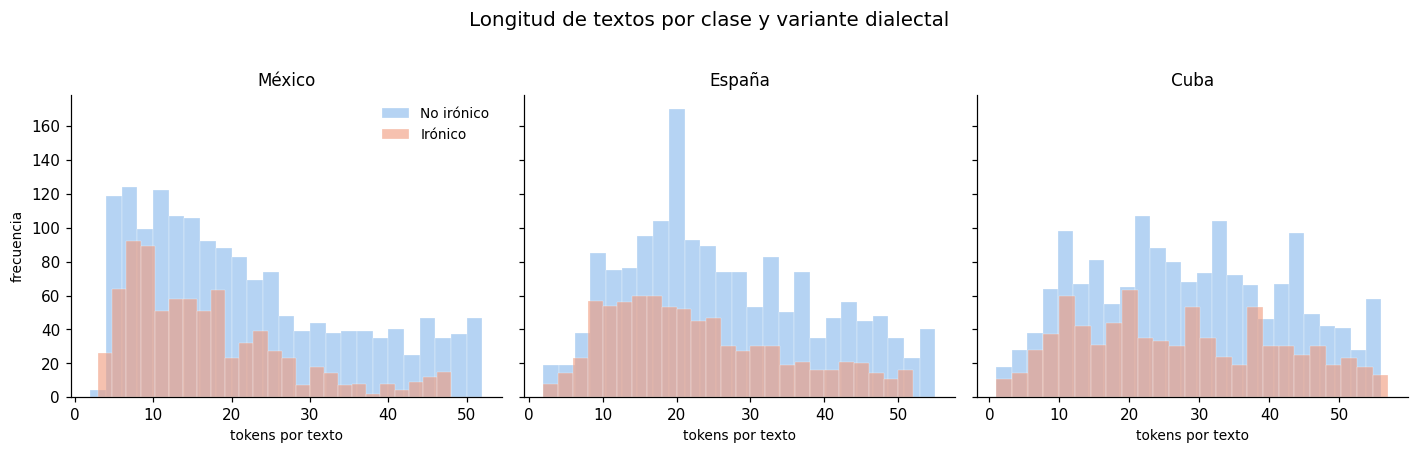

In [16]:
# Visualización de longitud de textos por variante y clase
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, (nombre, df) in zip(axes, DATASETS[:-1]):
    for label, color, etiq in [(0, '#85B7EB', 'No irónico'), (1, '#F0997B', 'Irónico')]:
        lon = df[df['IS_IRONIC']==label]['MESSAGE'].apply(
            lambda x: len(tokenizar_simple(x))
        )
        ax.hist(lon.clip(upper=lon.quantile(0.99)), bins=25,
                alpha=0.6, color=color, label=etiq, edgecolor='white', linewidth=0.3)
    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel('tokens por texto', fontsize=9)
    if ax == axes[0]:
        ax.set_ylabel('frecuencia', fontsize=9)
        ax.legend(fontsize=9, frameon=False)

fig.suptitle('Longitud de textos por clase y variante dialectal', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()